In [3]:
import numpy as np
import matplotlib.pyplot as plt
import sounddevice as sd

Задание. Сгенерите розовый шум путем первой генерации сигнала белого шума, преобразования его Фурье, затем деления амплитуд различных частотных составляющих на квадратный корень из частоты.

Вам понадобятся функции np.fft.rfft , np.real , np.sqrt

In [1]:
import numpy as np

duration = 5.0
sample_rate = 4100
n_samples = int(duration * sample_rate)

white_noise = np.random.random(n_samples)

# Преобразование Фурье
freq_domain = np.fft.rfft(white_noise)

# Получение частот
freqs = np.fft.rfftfreq(n_samples, 1/sample_rate)
freqs_for_scaling = np.where(freqs == 0, 1e-10, freqs)

# Деление амплитуд на квадратный корень из частоты
scaled_freq_domain = freq_domain / np.sqrt(freqs_for_scaling)

# Обратное преобразование Фурье
pink_noise_complex = np.fft.irfft(scaled_freq_domain)

# Извлечение действительной части
pink_noise = np.real(pink_noise_complex)

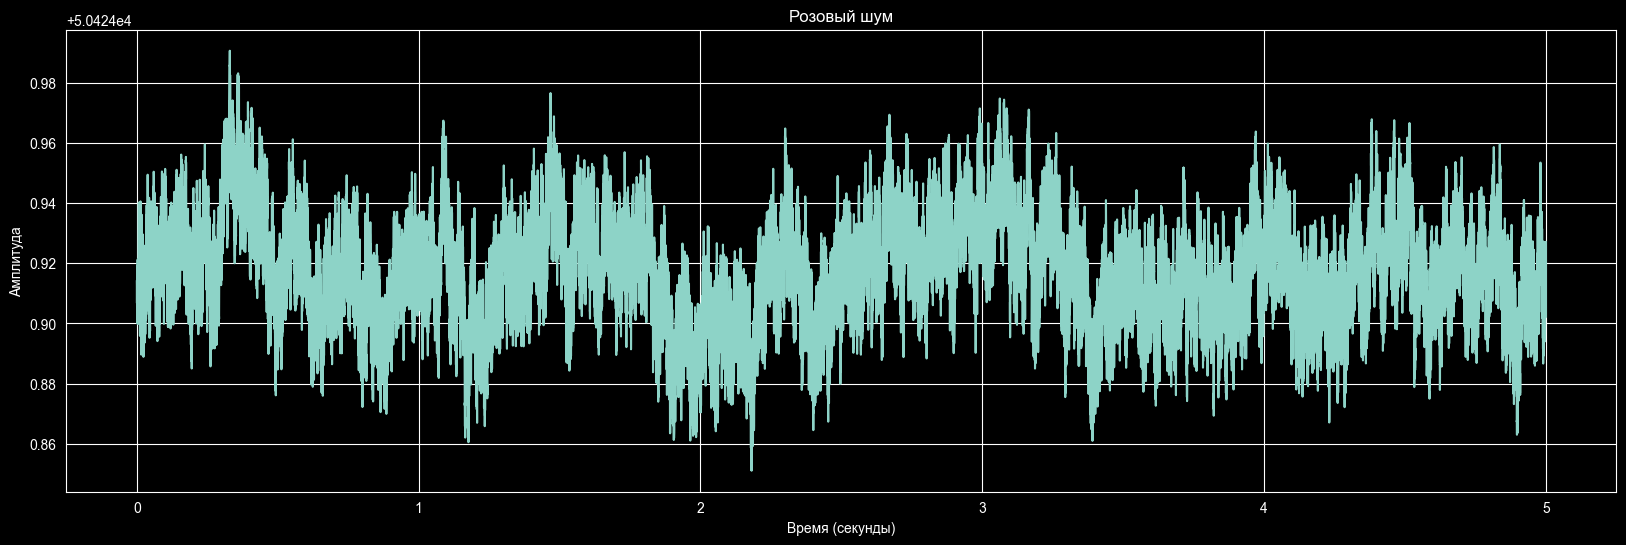

In [5]:
# отрисовываем, что получилось
# создаем временную шкалу. Считаем, что она начинается с 0, до окончания записи (duretion).
# Между этими значениями равномерно заполняем ряд time_axis, чтобы в нем оказалось ровно столько элементов, сколько во временном ряду
time_axis = np.linspace(0, duration, len(pink_noise))

# заданем параметры полотна, на котором будем рисовать
plt.figure(figsize=(20, 6))

# определяем, что будем отрисовывать. По x - time_axis, по y - white_noise_simple
plt.plot(time_axis, pink_noise)

# заголовки
plt.title('Розовый шум')
plt.xlabel('Время (секунды)')
plt.ylabel('Амплитуда')

# команда на отрисовку
plt.show()